In [1]:
import pandas as pd
from training_logs_analysis import parse_client_csv, process_fp_logs


In [2]:
path = "/home/brian_bosho/FP/FP/federated-gnn/src/results/yaml_test_results_5clients/Cora_adjacency_GCN/training_Cora_adjacency_GCN_20250503_211641.csv"

In [3]:
dfs = parse_client_csv(path)

In [4]:
dfs.keys()


dict_keys(['loss_df', 'acc_df', 'loss_df_step', 'acc_df_step', 'avg_loss_df', 'avg_acc_df', 'epoch_loss_df', 'epoch_acc_df', 'final_loss_df', 'final_acc_df'])

In [5]:
final_loss_df = dfs['final_loss_df']
final_loss_df


client_id,0,1,2,3,4
round,,,,,
0,1.511729,1.714927,1.316724,1.608046,1.553374
1,1.352808,1.380581,1.075114,1.522972,1.327772
2,1.155474,1.090317,0.905097,1.379927,1.254807
3,0.986516,1.092607,0.762016,1.224443,1.042193
4,0.971870,0.914589,0.600787,1.175818,0.988997
5,0.765988,0.721967,0.586181,1.051511,0.901258
6,0.914893,0.707734,0.423998,0.956108,0.816093
7,0.663801,0.594324,0.370145,0.873491,0.706497
8,0.742756,0.664011,0.435593,0.722421,0.731878


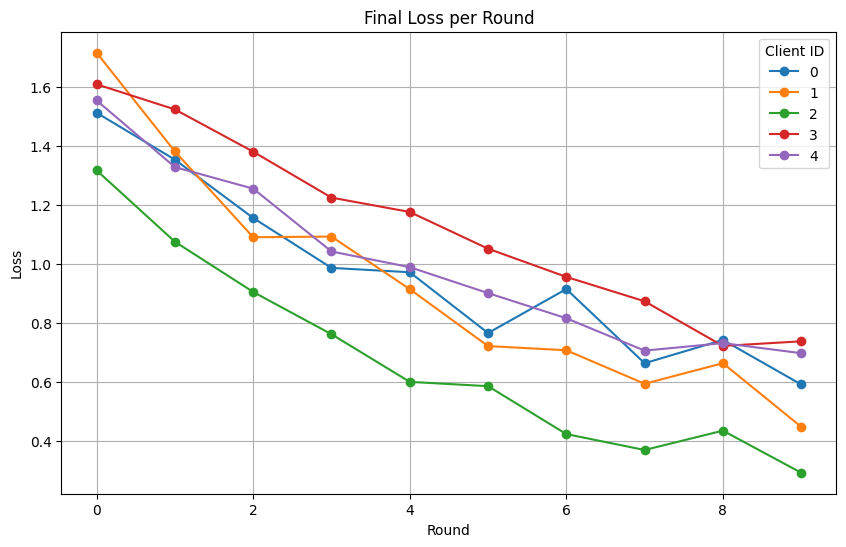

In [6]:
# plot final loss
import matplotlib.pyplot as plt
final_loss_df.plot(figsize=(10, 6), marker='o')
plt.title("Final Loss per Round")
plt.xlabel("Round")
plt.ylabel("Loss")
plt.grid(True)
plt.legend(title="Client ID")

### lets review the results folder results

In [1]:
from process_results import process_results_folder_json

In [2]:
test_results = "/home/brian_bosho/FP/FP/federated-gnn/src/results/yaml_test_results_5clients"

In [3]:
df = process_results_folder_json(test_results)
df

INFO: Scanning folder: /home/brian_bosho/FP/FP/federated-gnn/src/results/yaml_test_results_5clients
INFO: Reading: /home/brian_bosho/FP/FP/federated-gnn/src/results/yaml_test_results_5clients/Cora_adjacency_GCN/results_Cora_adjacency_GCN_20250503_211641.json
INFO: Reading: /home/brian_bosho/FP/FP/federated-gnn/src/results/yaml_test_results_5clients/Cora_full_GCN/results_Cora_full_GCN_20250503_211618.json
INFO: Successfully created DataFrame with 2 rows.


,device,data_loading_option,model_type,dataset,num_clients,beta,hop,fulltraining_flag,global_results,client_results,average_global_result,average_client_result,std_global,std_client,experiment_id
0,cuda,adjacency,GCN,Cora,5,1,1,False,[0.656],[0.6805602731152979],0.656,0.680560,0.0,0.0,results_Cora_adjacency_GCN_20250503_211641
1,cuda,full,GCN,Cora,5,1,1,False,[0.7],[0.7063045451617194],0.700,0.706305,0.0,0.0,results_Cora_full_GCN_20250503_211618


### FP logs

In [4]:
iid_json = "/home/brian_bosho/FP/FP/federated-gnn/logs/propagation_stats/prop_exp_20250504-032223_adjacency_beta_10000_hop_1.json"
stats = process_fp_logs(iid_json)

stats.keys()


dict_keys(['fp_stats_df', 'deltas_df', 'energy_raw_df', 'energy_per_node_df', 'energy_per_edge_df'])

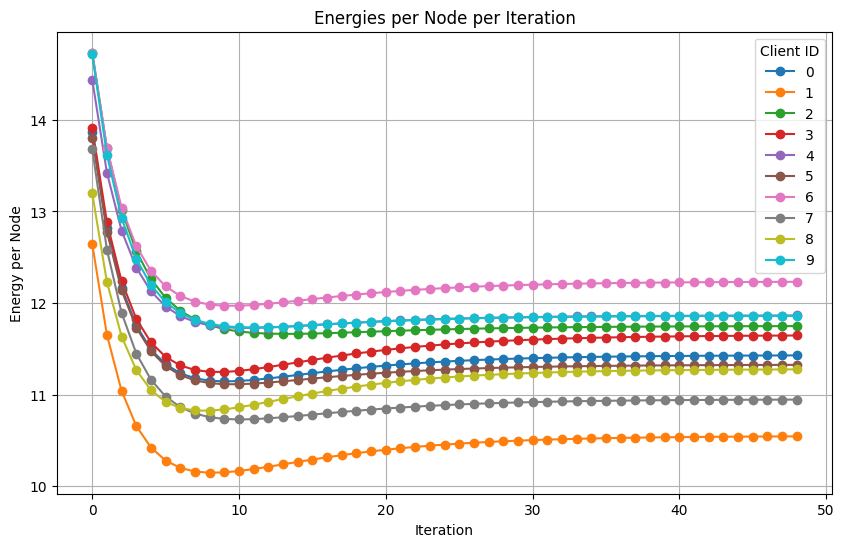

In [7]:
iid_energy_per_node_df = stats["energy_per_node_df"]
iid_energy_per_node_df

# plot
import matplotlib.pyplot as plt
iid_energy_per_node_df.plot(figsize=(10, 6), marker='o')
plt.title("Energies per Node per Iteration iid")
plt.xlabel("Iteration")
plt.ylabel("Energy per Node")
plt.grid(True)
plt.legend(title="Client ID")